<a href="https://colab.research.google.com/github/youmna-abdelaty/hotel-booking-cancellation-prediction/blob/main/notebooks/hotel_booking_cancellation_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Import Libraries

In [49]:
import pandas as pd
import numpy as np
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Dataset

In [4]:
df = pd.read_csv("/content/hotel_bookings.csv")

In [5]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


# Exploratory Data Analysis (EDA)

In [6]:
print(df.columns)

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')


In [7]:
print(df.shape)

(29264, 32)


In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29264 entries, 0 to 29263
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           29264 non-null  object 
 1   is_canceled                     29264 non-null  int64  
 2   lead_time                       29264 non-null  int64  
 3   arrival_date_year               29264 non-null  int64  
 4   arrival_date_month              29264 non-null  object 
 5   arrival_date_week_number        29264 non-null  int64  
 6   arrival_date_day_of_month       29264 non-null  int64  
 7   stays_in_weekend_nights         29264 non-null  int64  
 8   stays_in_week_nights            29264 non-null  int64  
 9   adults                          29264 non-null  int64  
 10  children                        29264 non-null  int64  
 11  babies                          29264 non-null  int64  
 12  meal                            

In [9]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,29264.000000,29264.000000,29264.000000,29264.000000,29264.000000,29264.000000,29264.000000,29264.000000,29264.000000,29264.000000,29264.000000,29264.000000,29264.000000,29264.000000,23221.000000,2351.000000,29264.000000,29264.000000,29264.000000,29264.000000
mean,0.379716,98.071453,2015.878144,28.171918,15.723141,1.199289,3.159069,1.875239,0.132381,0.013464,0.048900,0.139079,0.185142,0.260867,214.380345,224.101234,0.597048,95.116157,0.122403,0.560689
std,0.485324,99.541516,0.656899,13.364027,8.854226,1.144869,2.448000,0.768567,0.455187,0.116724,0.215662,1.560389,1.154339,0.691890,84.038022,114.949902,7.910657,60.679642,0.335179,0.781501
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,13.000000,2015.000000,17.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,208.000000,135.000000,0.000000,50.400000,0.000000,0.000000
50%,0.000000,65.000000,2016.000000,30.000000,16.000000,1.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,240.000000,223.000000,0.000000,76.000000,0.000000,0.000000
75%,1.000000,163.000000,2016.000000,39.000000,23.000000,2.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,242.000000,291.500000,0.000000,126.600000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,2.000000,1.000000,26.000000,30.000000,17.000000,531.000000,543.000000,150.000000,508.000000,8.000000,5.000000


## Identify all missing values

In [10]:
# Calculate total count and percentage of missing values per column
missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df)) * 100
})
# Keep only columns that contain missing values
missing_df = missing_df[missing_df['Missing Count'] > 0]

# Sort values in descending order
missing_df = missing_df.sort_values(by='Missing Count', ascending=False)
missing_df

,Missing Count,Percentage
company,26913,91.966238
agent,6043,20.649945
country,461,1.575314


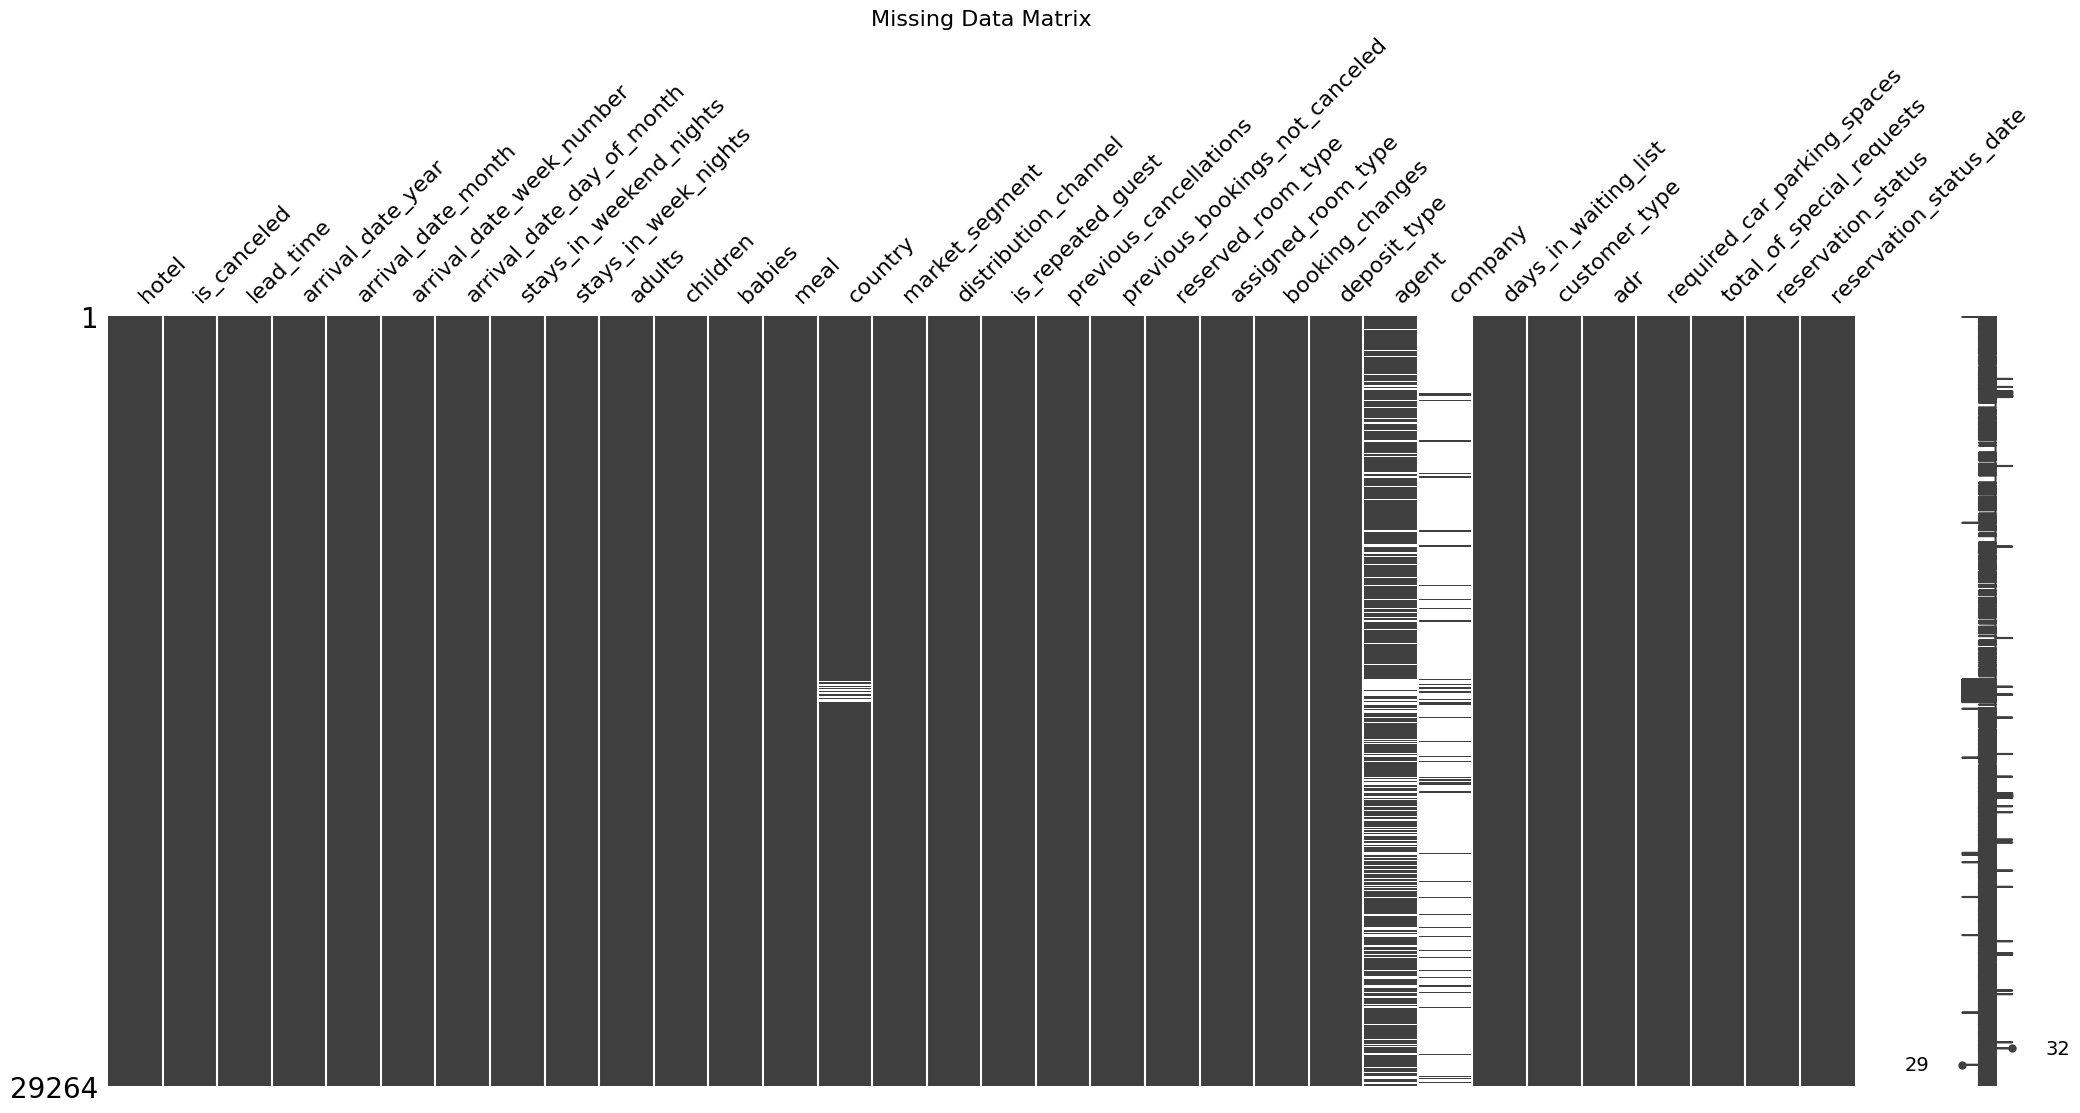

In [11]:
# Plot the Missingno Matrix to view patterns of missing data across all rows
msno.matrix(df)
plt.title('Missing Data Matrix', fontsize=16)
plt.show()

**Insight:**

>The missingno matrix illustrates that missing data is heavily concentrated in specific columns rather than spread across complete rows.

>company exhibits extreme missingness (94.3%), followed by agent (13.7%).

> country and children have the fewest missing values (<0.5%).

> The row completeness sparkline confirms that no rows are entirely empty, as every record retains at least 29 out of 32 populated features.

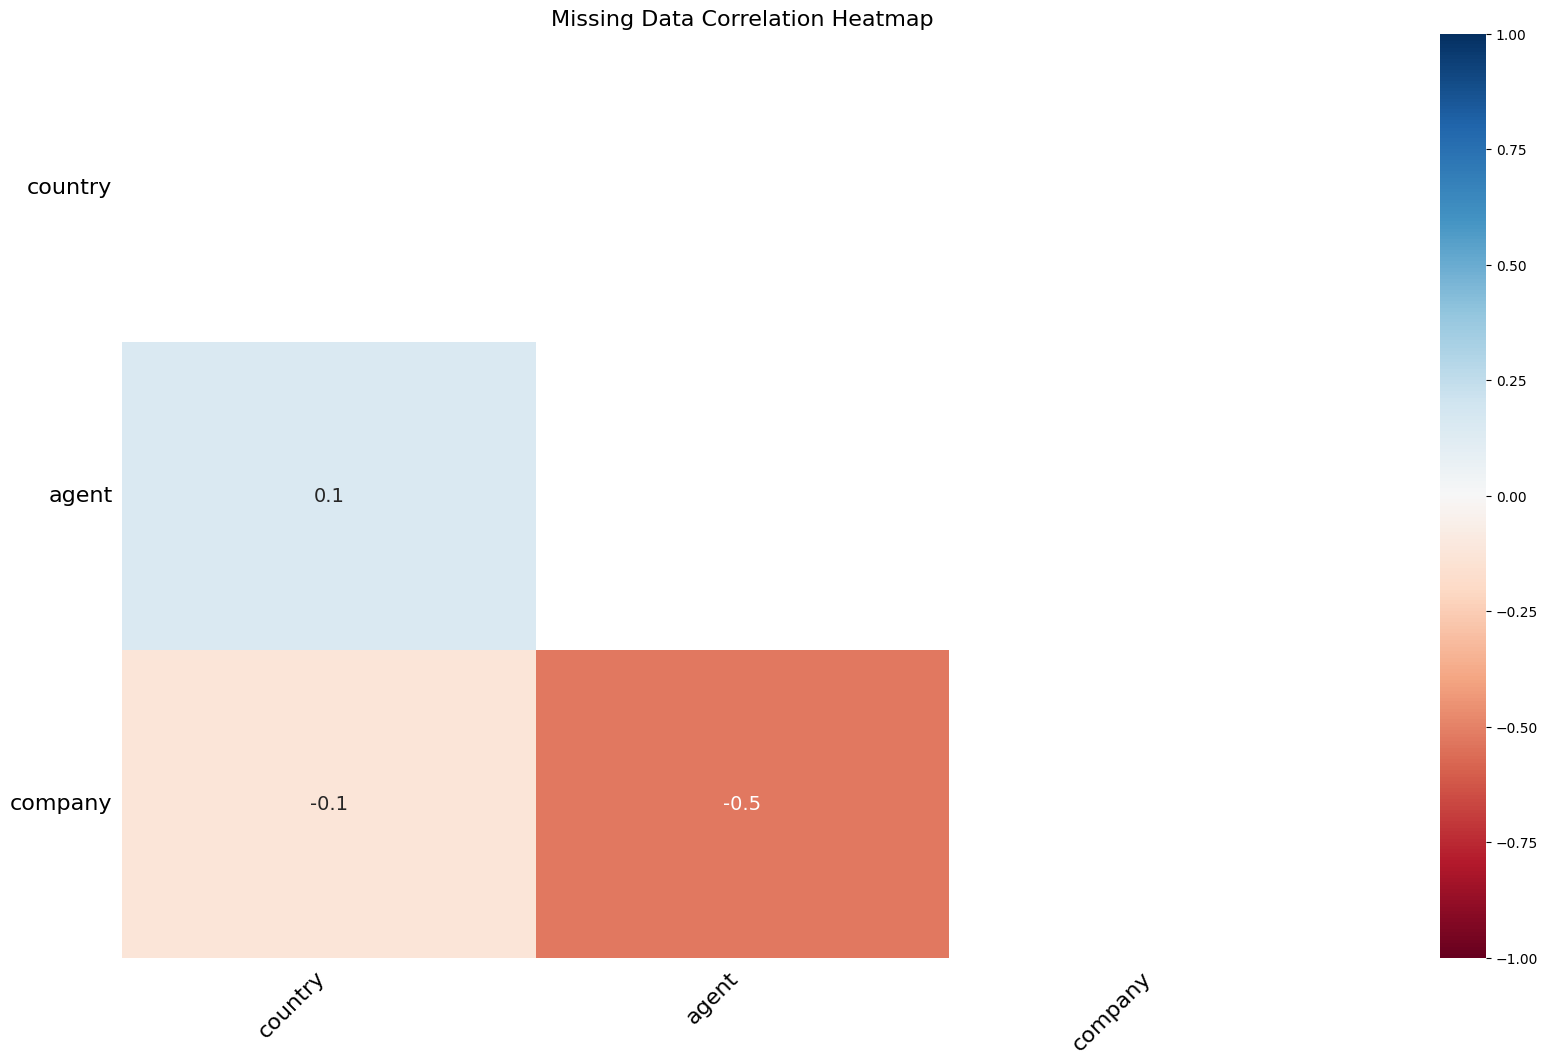

In [12]:
# Plot the Missingno Heatmap to check correlations between missing columns
msno.heatmap(df)
plt.title('Missing Data Correlation Heatmap', fontsize=16)
plt.show()

**Insight:**

>The missingno heatmap reveals a notable negative correlation (-0.6) between company and agent missing values.

>This indicates a structured missing pattern (MNAR - Missing Not At Random), where bookings typically utilize either a travel agent or a corporate company, but rarely both simultaneously.

## Detect Outliers

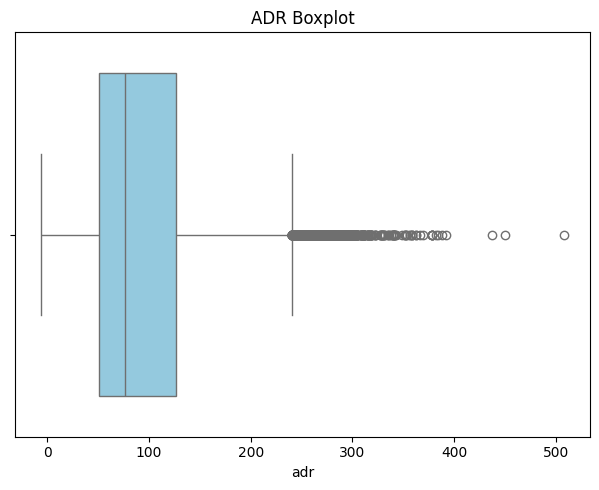

In [13]:
# Boxplot for adr
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df['adr'], color='skyblue')
plt.title('ADR Boxplot')

plt.tight_layout()
plt.show()

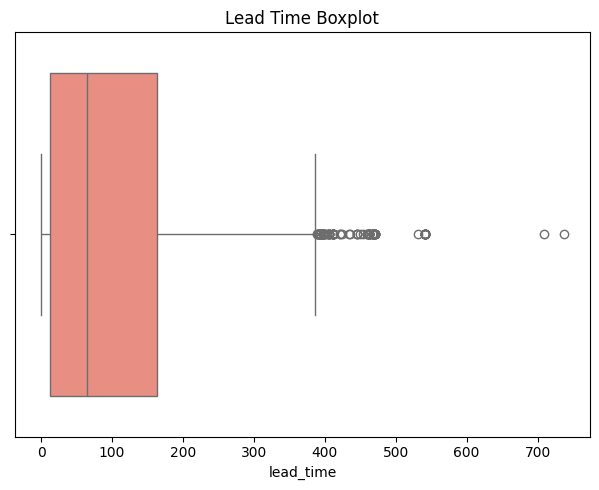

In [14]:
# Boxplot for lead_time
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 2)
sns.boxplot(x=df['lead_time'], color='salmon')
plt.title('Lead Time Boxplot')

plt.tight_layout()
plt.show()

In [15]:
# Define key columns to check for outliers
columns_to_check = ['adr', 'lead_time']

# Calculate Q1 and Q3
for col in columns_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Calculate IQR
    IQR = Q3 - Q1

    # Calculate lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    # Calculate count and percentage of outliers
    outlier_count = len(outliers)
    percentage = (outlier_count / len(df)) * 100

    # Display results
    print(f"=== Outliers in '{col}' ===")
    print(f"Lower Bound: {lower_bound:.2f}")
    print(f"Upper Bound: {upper_bound:.2f}\n")

    print(f"Outlier Count: {outlier_count}")
    print(f"Percentage: {percentage:.2f}%\n")

=== Outliers in 'adr' ===
Lower Bound: -63.90
Upper Bound: 240.90

Outlier Count: 816
Percentage: 2.79%

=== Outliers in 'lead_time' ===
Lower Bound: -212.00
Upper Bound: 388.00

Outlier Count: 201
Percentage: 0.69%



## Summary: Main Data Quality Issues Identified

### 1. Data Integrity & Data Types
* `reservation_status_date` is stored as an `object` (string) instead of `datetime`.

* `children` is stored as a `float64` (float) instead of `int64` (integer), despite representing discrete counts.

### 2. Missing Data Patterns
* **High Missingness Columns:**
  * `company`: **94.3% missing** (112,593 rows).
  * `agent`: **13.7% missing** (16,340 rows).
* **Minor Missingness:** `country` (0.41%) and `children` (0.003%).
* **Missingness Pattern:** A strong negative correlation (**-0.6**) exists between `company` and `agent`, indicating that guests usually book either through an agent or a company, but rarely both (MNAR pattern).

### 3. Presence of Outliers
* **`adr` (Average Daily Rate):** Significant upper-bound outliers detected, representing values far above the standard daily rates.
* **`lead_time`:** Contains numerous upper-bound outliers representing bookings made very far in advance, exceeding the IQR threshold.

# Data Cleaning

## Handle Missing Values

In [16]:
# 1. Handle Missing Values in 'company' and 'agent'
# Replace NaN values with 0 to represent 'No Agent' or 'No Company'
df['company'] = df['company'].fillna(0)
df['agent'] = df['agent'].fillna(0)

# 2. Handle Missing Values in 'country'
# Impute missing values with the most frequent country (Mode)
df['country'] = df['country'].fillna(df['country'].mode()[0])

# 3. Handle Missing Values in 'children'
# Impute the 4 missing records with the mode (0 children)
df['children'] = df['children'].fillna(df['children'].mode()[0])

In [17]:
# 4. Verify that all missing values have been successfully handled
print("\nTotal missing values in the dataset:", df.isnull().sum().sum())


Total missing values in the dataset: 0


## Remove Duplicates

In [18]:
# Check total duplicate count before dropping
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

Number of duplicate rows found: 5025


In [19]:
# Drop duplicates and reset dataframe index
df = df.drop_duplicates().reset_index(drop=True)

In [20]:
# Check total duplicate count after dropping
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

Number of duplicate rows found: 0


## Handle Outliers

In [21]:
# List of numerical columns requiring outlier capping
target_columns = ['adr', 'lead_time']

# Loop through each column to dynamically calculate bounds and cap outliers
for col in target_columns:
    # 1. Calculate Quartiles and IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # 2. Calculate Upper Bound
    upper_bound = Q3 + (1.5 * IQR)

    # 3. Apply Capping (Lower limit = 0, Upper limit = calculated upper_bound)
    df[col] = df[col].clip(lower=0, upper=upper_bound)

    # 4. Print summary metrics for verification
    print(f"=== Outlier Capping Report for '{col}' ===")
    print(f"Calculated Upper Bound: {upper_bound:.2f}")
    print(f"New Max Value after capping: {df[col].max():.2f}\n")

=== Outlier Capping Report for 'adr' ===
Calculated Upper Bound: 261.75
New Max Value after capping: 261.75

=== Outlier Capping Report for 'lead_time' ===
Calculated Upper Bound: 344.00
New Max Value after capping: 344.00



## Outlier Handling & Justification

* **Applied Method:** Interquartile Range (IQR) limits (Q3 + 1.5 * IQR) with a lower limit of 0.
* **Capping Thresholds:**
  * **adr Upper Bound:** 227.00
  * **lead_time Upper Bound:** 296.00 days
  * **Lower Limit:** 0.00 (Enforced to prevent invalid negative values).

* **Justification:**
    * Rather than relying on hardcoded limits, the **Interquartile Range (IQR)** method calculates mathematically objective thresholds based on the actual distribution of the dataset.

    * Enforcing a strict lower bound of `0.00` bridges statistical math with business logic—correcting invalid negative rate errors while maintaining legitimate complimentary/free stays.

## Fix Data Types

In [24]:
# 1. Convert 'reservation_status_date' to datetime (handling mixed date formats)
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'], format='mixed')

# 2. Convert 'children' to integer
df['children'] = df['children'].astype(int)

# Verify changes
print(df[['reservation_status_date', 'children']].dtypes)

reservation_status_date    datetime64[ns]
children                            int64
dtype: object


# Feature Engineering & Preprocessing

## Create New Features

In [27]:
# 1. Total number of guests per booking
df['total_guests'] = df['adults'] + df['children'] + df['babies']

# 2. Total duration of stay (in nights)
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# 3. Binary flag for Family bookings (Yes if children or babies > 0, else No)
df['is_family'] = np.where((df['children'] > 0) | (df['babies'] > 0), 1, 0)

# Verify the newly created features
df.head(3)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests,total_nights,is_family
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,2015-07-01,2,0,0
1,Resort Hotel,0,344,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,2015-07-01,2,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1,0


In [26]:
# Another way to create: df['is_family']

# Check if the booking includes children or babies
# has_kids = (df['children'] > 0) | (df['babies'] > 0)

# Convert boolean flags (True/False) to binary integers (1/0)
# df['is_family'] = has_kids.map({True: 1, False: 0})

## Encode Categorical Variables

In [29]:
# Check unique values count for all categorical columns (Sorted Descending)
df.select_dtypes(include=['object']).nunique().sort_values(ascending=False)

,0
country,113
arrival_date_month,12
assigned_room_type,11
reserved_room_type,10
market_segment,6
meal,5
distribution_channel,4
customer_type,4
deposit_type,3
reservation_status,3


### Categorical Feature Cardinality Analysis

* **High-Cardinality Feature:**
  * `country` contains **113 unique values**, representing high cardinality. Direct One-Hot Encoding would drastically expand feature space; thus, grouping infrequent categories into an `'Other'` group is required.

* **Low-Cardinality Features:**
  * Features such as `arrival_date_month`, `assigned_room_type`, `reserved_room_type`, `market_segment`, `meal`, `customer_type`, `distribution_channel`, `deposit_type`, and `reservation_status` have low cardinality (ranging from **3 to 12 unique values**). These are ideal candidates for **One-Hot Encoding**. *italicized text*

* **Zero/Low Variance Feature:**
  * `hotel` has only **1 unique value** in this subset, indicating no variability, making it a candidate for removal before modeling.

### Encoding low-cardinality catigorical columns

In [30]:
# List of low-cardinality categorical columns to encode
low_cardinality_cols = [
    'arrival_date_month',
    'meal',
    'market_segment',
    'distribution_channel',
    'reserved_room_type',
    'assigned_room_type',
    'deposit_type',
    'customer_type'
]

# Apply One-Hot Encoding
df = pd.get_dummies(df, columns=low_cardinality_cols, drop_first=True, dtype=int)

# Verify updated columns
df.head(3)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,assigned_room_type_G,assigned_room_type_H,assigned_room_type_I,assigned_room_type_L,assigned_room_type_P,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,Resort Hotel,0,342,2015,27,1,0,0,2,0,...,0,0,0,0,0,0,0,0,1,0
1,Resort Hotel,0,344,2015,27,1,0,0,2,0,...,0,0,0,0,0,0,0,0,1,0
2,Resort Hotel,0,7,2015,27,1,0,1,1,0,...,0,0,0,0,0,0,0,0,1,0


### Encoding high-cardinality catigorical columns



In [33]:
# Calculate the frequency of each value in the 'country' column
country_counts = df['country'].value_counts()

# Set a threshold (any country appearing in less than 1% of total rows)
threshold = len(df) * 0.01

# Get countries with counts below the threshold
rare_countries = country_counts[country_counts < threshold].index

# Replace rare countries with "Other"
df['country'] = df['country'].apply(lambda x: 'Other' if x in rare_countries else x)

print(df['country'].nunique())

12


In [35]:
# Convert the 'country' column to numerical values using One-Hot Encoding
df = pd.get_dummies(df, columns=['country'], drop_first=True, dtype=int)

In [36]:
# Verify updated columns
df.head(3)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,country_DEU,country_ESP,country_FRA,country_GBR,country_IRL,country_ITA,country_NLD,country_Other,country_PRT,country_USA
0,Resort Hotel,0,342,2015,27,1,0,0,2,0,...,0,0,0,0,0,0,0,0,1,0
1,Resort Hotel,0,344,2015,27,1,0,0,2,0,...,0,0,0,0,0,0,0,0,1,0
2,Resort Hotel,0,7,2015,27,1,0,1,1,0,...,0,0,0,1,0,0,0,0,0,0


# Data Leakage Prevention & Train-Test Split

In [45]:
# Drop columns causing data leakage
df = df.drop(columns=['reservation_status', 'reservation_status_date'], errors = 'ignore')

# Drop zero-variance column
df = df.drop(columns=['hotel'], errors = 'ignore')


print(df.shape)  # confirm columns were dropped


(24239, 81)


In [46]:
# Separate Features (X) and Target (y)
X = df.drop(columns=['is_canceled'])
y = df['is_canceled']

In [48]:
# Split Dataset into Train and Test Sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [50]:
# Standardize features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)